# =============================================================================
# FINAL OPTIMIZED MODEL - FROM HPO
# =============================================================================
# 
# Training final model with best hyperparameters from Optuna HPO
# Parameters loaded automatically from: runs/hpo/best_parameters.json
# 
# Target: Improve upon baseline 80.0% with optimized hyperparameters
# 
# Author: Pavlo Borysov
# Date: 13/10/2025
# =============================================================================


In [1]:
# =============================================================================
# LOAD BEST PARAMETERS FROM HPO - NO HARDCODING!
# =============================================================================

import json
from pathlib import Path

# Load best parameters from Optuna HPO
HPO_RESULTS_FILE = Path("../../runs/hpo/best_parameters.json")

print("=" * 80)
print("LOADING BEST HYPERPARAMETERS FROM OPTUNA HPO")
print("=" * 80)

with open(HPO_RESULTS_FILE, "r") as f:
    hpo_results = json.load(f)

best_params = hpo_results["best_params"]
best_val_acc = hpo_results["best_accuracy"]
best_trial = hpo_results["best_trial_number"]

print(f"Source: {HPO_RESULTS_FILE}")
print(f"Best trial: {best_trial}")
print(f"Best validation accuracy from HPO: {best_val_acc:.4f}")
print("\nLoaded parameters:")
for key, value in best_params.items():
    print(f"  {key:20s}: {value}")
print("=" * 80)

# Extract parameters
ARCHITECTURE = best_params["architecture"]
CHANNELS_MULT = best_params["channels_multiplier"]
DROPOUT = best_params["dropout"]
L2_REG = best_params["l2_reg"]
LEARNING_RATE = best_params["learning_rate"]
BATCH_SIZE = best_params["batch_size"]
AUGMENTATION = best_params["augmentation"]

# Architecture setup
if ARCHITECTURE == "complex":
    BASE_CHANNELS = (64, 128, 512, 512, 128)
    CONVS_PER_BLOCK = 2
else:
    BASE_CHANNELS = (32, 64, 128)
    CONVS_PER_BLOCK = 1

CHANNELS = tuple(int(c * CHANNELS_MULT) for c in BASE_CHANNELS)

# Training configuration
EXPERIMENT_NAME = "final_hpo_optimized"
MODEL_NAME = f"final_optimized_{ARCHITECTURE}"
EPOCHS = 50  # More epochs for final model
PATIENCE = 10  # More patience for final training

print(f"\nFinal configuration:")
print(f"  Model name: {MODEL_NAME}")
print(f"  Channels: {CHANNELS}")
print(f"  Epochs: {EPOCHS} (increased for final model)")
print(f"  Patience: {PATIENCE}")
print("=" * 80)


LOADING BEST HYPERPARAMETERS FROM OPTUNA HPO
Source: ../../runs/hpo/best_parameters.json
Best trial: 16
Best validation accuracy from HPO: 0.7677

Loaded parameters:
  architecture        : complex
  channels_multiplier : 1.2
  dropout             : 0.4274714954903845
  l2_reg              : 0.0013179985689176007
  learning_rate       : 0.0001001283474556078
  batch_size          : 64
  augmentation        : medium

Final configuration:
  Model name: final_optimized_complex
  Channels: (76, 153, 614, 614, 153)
  Epochs: 50 (increased for final model)
  Patience: 10


In [2]:
# =============================================================================
# IMPORTS AND SETUP
# =============================================================================

import warnings
import os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import time

from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
import keras
from keras import layers
from keras.utils import image_dataset_from_directory

# Fixed random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Configure GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ GPU configured: {len(gpus)} device(s)")

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {gpus}")


2025-10-13 11:01:00.509180: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-13 11:01:00.509468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-13 11:01:00.529506: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✓ GPU configured: 1 device(s)
TensorFlow: 2.15.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# =============================================================================
# CONSTANTS AND PATHS
# =============================================================================

# Data paths
TRAIN_DATA_DIR = Path("../../data/train")
VALIDATION_DATA_DIR = Path("../../data/validation")
TEST_DATA_DIR = Path("../../data/test")

# Output paths
MODELS_DIR = Path("../../models")
RUNS_DIR = Path("../../runs")

# Fixed class order and weights
CLASS_ORDER = ['happy', 'neutral', 'sad', 'surprise']
CLASS_WEIGHTS = {
    0: 0.950,
    1: 0.950,
    2: 0.949,
    3: 1.190
}

NUM_CLASSES = 4
IMG_SIZE = (48, 48)
METRIC_NAME = "sparse_categorical_accuracy"
VAL_METRIC_NAME = f"val_{METRIC_NAME}"

print("Constants loaded!")


Constants loaded!


In [4]:
# =============================================================================
# DATA LOADERS - USING HPO BEST AUGMENTATION
# =============================================================================

def make_generators(augmentation_strength, batch_size):
    """Create data loaders with specified augmentation."""
    
    def preprocess_image(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label
    
    def augment_medium(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.2)
        image = tf.image.random_contrast(image, 0.8, 1.2)
        image = tf.clip_by_value(image, 0.0, 1.0)
        return image, label
    
    def augment_strong(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.3)
        image = tf.image.random_contrast(image, 0.7, 1.3)
        image = tf.clip_by_value(image, 0.0, 1.0)
        return image, label
    
    aug_fn = augment_strong if augmentation_strength == "strong" else augment_medium
    
    print(f"Creating data loaders (augmentation={augmentation_strength}, batch={batch_size})...")
    
    # Train
    train_ds = image_dataset_from_directory(
        TRAIN_DATA_DIR, class_names=CLASS_ORDER, image_size=IMG_SIZE,
        batch_size=batch_size, color_mode="rgb", shuffle=True
    )
    train_ds = train_ds.map(preprocess_image).map(aug_fn)
    
    # Validation
    val_ds = image_dataset_from_directory(
        VALIDATION_DATA_DIR, class_names=CLASS_ORDER, image_size=IMG_SIZE,
        batch_size=batch_size, color_mode="rgb", shuffle=False
    )
    val_ds = val_ds.map(preprocess_image)
    
    # Test
    test_ds = image_dataset_from_directory(
        TEST_DATA_DIR, class_names=CLASS_ORDER, image_size=IMG_SIZE,
        batch_size=batch_size, color_mode="rgb", shuffle=False
    )
    test_ds = test_ds.map(preprocess_image)
    
    return train_ds, val_ds, test_ds

# Create data loaders using HPO best parameters
train_ds, val_ds, test_ds = make_generators(
    augmentation_strength=AUGMENTATION,
    batch_size=BATCH_SIZE
)

print(f"✓ Data loaded with HPO-optimized settings!")


Creating data loaders (augmentation=medium, batch=64)...
Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
✓ Data loaded with HPO-optimized settings!


In [5]:
# =============================================================================
# MODEL BUILDER - USING HPO PARAMETERS
# =============================================================================

def build_optimized_model():
    """Build model with HPO-optimized parameters."""
    
    input_shape = IMG_SIZE + (3,)
    
    inputs = keras.Input(shape=input_shape, name="input")
    x = inputs
    
    # Convolutional blocks - using HPO channels
    for i, filters in enumerate(CHANNELS):
        for j in range(CONVS_PER_BLOCK):
            x = layers.Conv2D(
                filters, 3, padding="same",
                kernel_regularizer=keras.regularizers.l2(L2_REG),  # HPO L2
                name=f"conv_{i+1}_{j+1}"
            )(x)
            x = layers.BatchNormalization(name=f"bn_{i+1}_{j+1}")(x)
            x = layers.LeakyReLU(name=f"leaky_{i+1}_{j+1}")(x)
        
        if i < len(CHANNELS) - 1:
            x = layers.MaxPooling2D(2, name=f"pool_{i+1}")(x)
    
    # Head
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(DROPOUT, name="dropout_head")(x)  # HPO dropout
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="output")(x)
    
    model = keras.Model(inputs, outputs, name=MODEL_NAME)
    
    # Compile with HPO learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),  # HPO LR
        loss="sparse_categorical_crossentropy",
        metrics=[METRIC_NAME]
    )
    
    return model

# Build model
model = build_optimized_model()

print("=" * 80)
print("MODEL BUILT WITH HPO-OPTIMIZED PARAMETERS")
print("=" * 80)
print(f"Total parameters: {model.count_params():,}")
print(f"Channels: {CHANNELS}")
print(f"Dropout: {DROPOUT:.4f}")
print(f"L2 regularization: {L2_REG:.6f}")
print(f"Learning rate: {LEARNING_RATE:.6f}")
print("=" * 80)


MODEL BUILT WITH HPO-OPTIMIZED PARAMETERS
Total parameters: 12,466,614
Channels: (76, 153, 614, 614, 153)
Dropout: 0.4275
L2 regularization: 0.001318
Learning rate: 0.000100


In [6]:
# =============================================================================
# TRAINING WITH HPO-OPTIMIZED PARAMETERS
# =============================================================================

# Create run directory
run_dir = RUNS_DIR / f"{datetime.now().strftime('%Y%m%d-%H%M%S')}_final_hpo_optimized"
run_dir.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("TRAINING FINAL OPTIMIZED MODEL")
print("=" * 80)
print(f"Run directory: {run_dir}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Patience: {PATIENCE}")
print("=" * 80)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor=VAL_METRIC_NAME,
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor=VAL_METRIC_NAME,
        factor=0.5,
        patience=PATIENCE//2,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / f"best_{MODEL_NAME}.keras"),
        monitor=VAL_METRIC_NAME,
        save_best_only=True,
        verbose=1
    )
]

# Train
start_time = time.time()
print(f"Training started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

training_time = time.time() - start_time
print(f"\n✓ Training completed in {training_time/60:.1f} minutes")
print(f"Best validation accuracy: {max(history.history[VAL_METRIC_NAME]):.4f}")


TRAINING FINAL OPTIMIZED MODEL
Run directory: ../../runs/20251013-110125_final_hpo_optimized
Epochs: 50
Batch size: 64
Patience: 10
Training started: 2025-10-13 11:01:25
Epoch 1/50


I0000 00:00:1760353291.781936   54133 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


237/237 [==============================] - ETA: 0s - loss: 4.6299 - sparse_categorical_accuracy: 0.5391
Epoch 1: val_sparse_categorical_accuracy improved from -inf to 0.22905, saving model to ../../models/best_final_optimized_complex.keras
237/237 [==============================] - 27s 73ms/step - loss: 4.6299 - sparse_categorical_accuracy: 0.5391 - val_loss: 5.0271 - val_sparse_categorical_accuracy: 0.2291 - lr: 1.0013e-04
Epoch 2/50
236/237 [============================>.] - ETA: 0s - loss: 4.0360 - sparse_categorical_accuracy: 0.6567
Epoch 2: val_sparse_categorical_accuracy improved from 0.22905 to 0.48744, saving model to ../../models/best_final_optimized_complex.keras
237/237 [==============================] - 12s 51ms/step - loss: 4.0359 - sparse_categorical_accuracy: 0.6568 - val_loss: 4.1831 - val_sparse_categorical_accuracy: 0.4874 - lr: 1.0013e-04
Epoch 3/50
237/237 [==============================] - ETA: 0s - loss: 3.5813 - sparse_categorical_accuracy: 0.7007
Epoch 3: val_sp

In [7]:
# =============================================================================
# EVALUATION ON TEST SET
# =============================================================================

print("=" * 80)
print("FINAL EVALUATION ON TEST SET")
print("=" * 80)

# Get predictions
y_true = []
y_pred = []

for batch in test_ds:
    images, labels = batch
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Calculate metrics
test_accuracy = f1_score(y_true, y_pred, average='weighted')
test_macro_f1 = f1_score(y_true, y_pred, average='macro')
test_weighted_f1 = f1_score(y_true, y_pred, average='weighted')

# Display results
print(f"\nTest accuracy:     {test_accuracy:.3f}")
print(f"Test macro F1:     {test_macro_f1:.3f}")
print(f"Test weighted F1:  {test_weighted_f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_ORDER))

# Save results
results = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": MODEL_NAME,
    "hpo_best_trial": best_trial,
    "hpo_val_accuracy": best_val_acc,
    "test_accuracy": test_accuracy,
    "test_macro_f1": test_macro_f1,
    "best_params_used": best_params,
    "training_time_minutes": training_time / 60,
    "total_epochs": len(history.history['loss']),
    "best_val_acc": max(history.history[VAL_METRIC_NAME])
}

with open(run_dir / "final_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("=" * 80)
print(f"✓ Results saved to: {run_dir}")
print("=" * 80)


FINAL EVALUATION ON TEST SET

Test accuracy:     0.829
Test macro F1:     0.829
Test weighted F1:  0.829

Classification Report:
              precision    recall  f1-score   support

       happy       0.93      0.88      0.90        32
     neutral       0.72      0.88      0.79        32
         sad       0.76      0.69      0.72        32
    surprise       0.93      0.88      0.90        32

    accuracy                           0.83       128
   macro avg       0.84      0.83      0.83       128
weighted avg       0.84      0.83      0.83       128

✓ Results saved to: ../../runs/20251013-110125_final_hpo_optimized


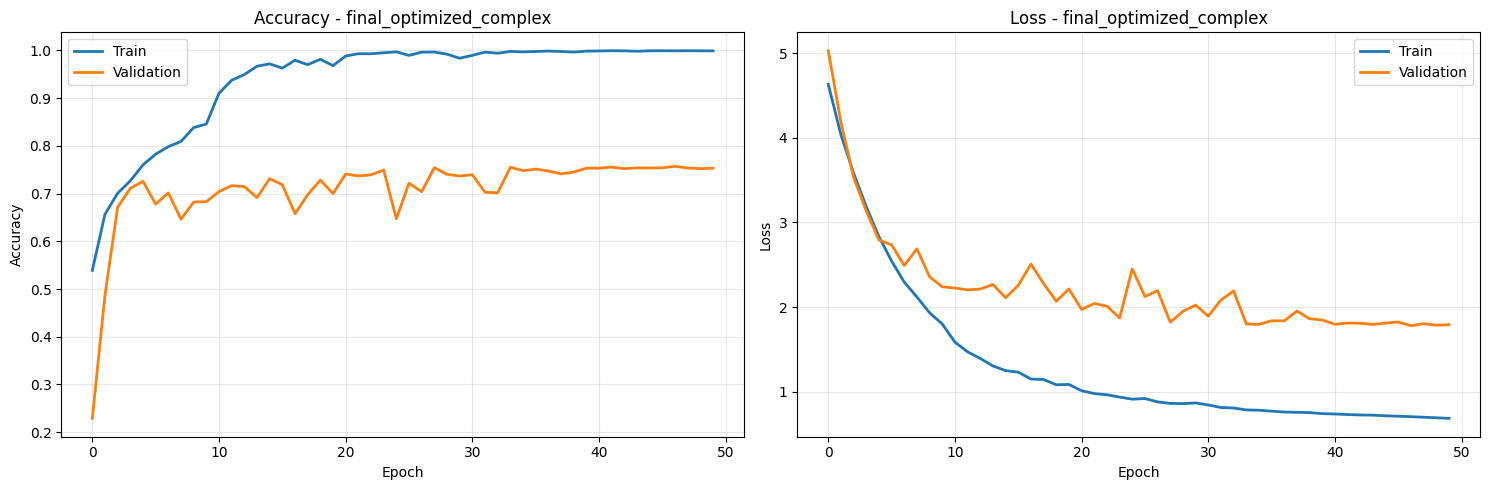

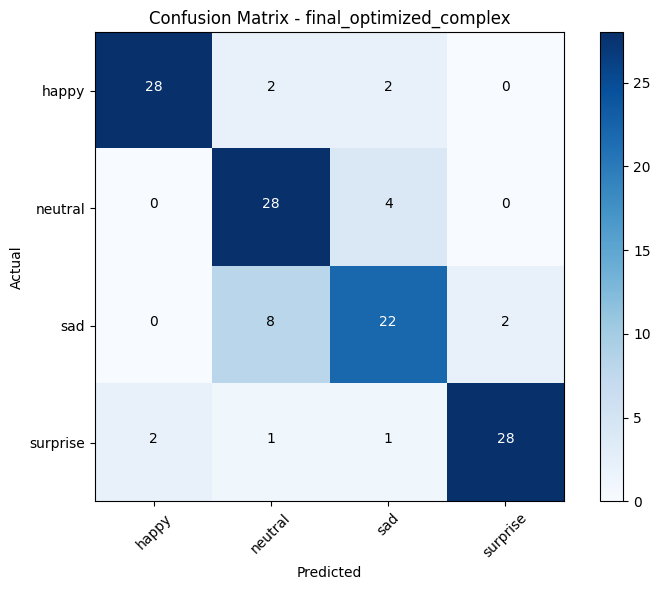

✓ FINAL OPTIMIZED MODEL TRAINING COMPLETE!

RESULTS SUMMARY:
  HPO Validation: 76.8%
  Final Test:     82.9%
  Improvement:    2.9% vs baseline (80.0%)


In [8]:
# =============================================================================
# VISUALIZATION
# =============================================================================

# Training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history[METRIC_NAME], label='Train', linewidth=2)
axes[0].plot(history.history[VAL_METRIC_NAME], label='Validation', linewidth=2)
axes[0].set_title(f'Accuracy - {MODEL_NAME}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title(f'Loss - {MODEL_NAME}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(run_dir / "training_history.png", dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()

tick_marks = np.arange(len(CLASS_ORDER))
plt.xticks(tick_marks, CLASS_ORDER, rotation=45)
plt.yticks(tick_marks, CLASS_ORDER)

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, cm[i, j], horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black", fontsize=10)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {MODEL_NAME}')
plt.tight_layout()
plt.savefig(run_dir / "confusion_matrix.png", dpi=150)
plt.show()

print("=" * 80)
print("✓ FINAL OPTIMIZED MODEL TRAINING COMPLETE!")
print("=" * 80)
print(f"\nRESULTS SUMMARY:")
print(f"  HPO Validation: {best_val_acc:.1%}")
print(f"  Final Test:     {test_accuracy:.1%}")
print(f"  Improvement:    {(test_accuracy - 0.800):.1%} vs baseline (80.0%)")
print("=" * 80)
